🔥 1. INSTALL DEPENDENCIES


In [1]:
!pip install pandas numpy scikit-learn xgboost shap transformers datasets torch joblib


📁 2. IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import re
import joblib
import shap
import torch

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report


3. LOAD DATA

In [10]:
df = pd.read_csv(
    "/content/SMS_labelled_CSV.csv",
    sep=",",                    # if your file uses semicolons
    engine="python",
    on_bad_lines="skip",
)

LOAD DATA (Code)

In [40]:
print("Dataset Shape:", df.shape)
print("\nClass Distribution:")
print(df['label'].value_counts())
print("\nMissing Values:")
print(df.isnull().sum())


Dataset Shape: (7235, 4)

Class Distribution:
label
not_spam     3892
financial    1364
promotion    1029
lottery       612
fraud         201
otp           137
Name: count, dtype: int64

Missing Values:
TEXT             0
label            0
clean_text       0
label_encoded    0
dtype: int64


CLASS DISTRIBUTION VISUALIZATION (Code)

/tmp/ipykernel_26010/3979006653.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='Set2')


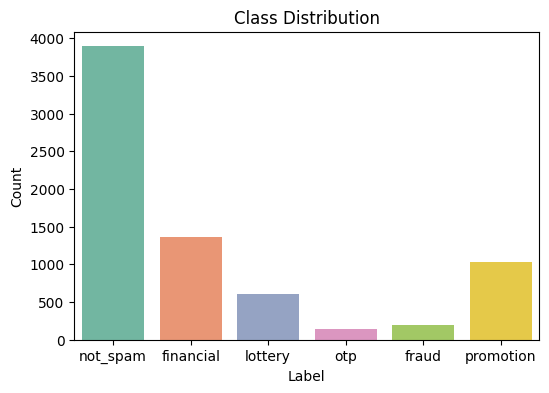

In [44]:
import pandas as pd
import numpy as np
import re
import joblib
import shap
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, palette='Set2')
plt.title('Class Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()


EXT LENGTH ANALYSIS (Code)

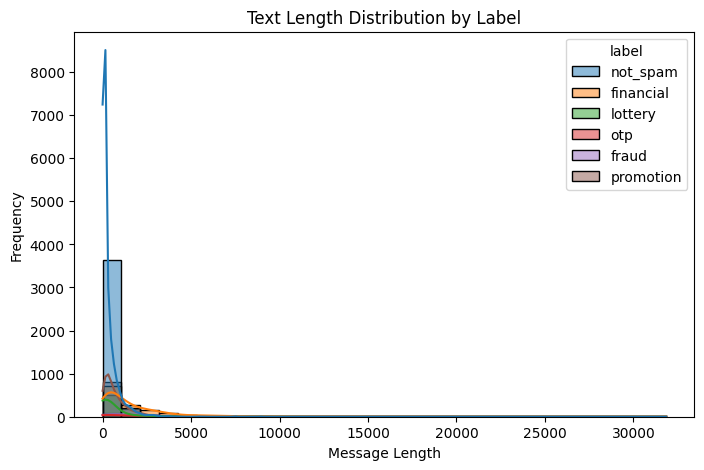

In [45]:
df['text_length'] = df['TEXT'].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='text_length', hue='label', bins=30, kde=True)
plt.title('Text Length Distribution by Label')
plt.xlabel('Message Length')
plt.ylabel('Frequency')
plt.show()


4. TEXT PREPROCESSING

In [26]:
df.columns

Index(['TEXT', 'label', 'clean_text', 'label_encoded'], dtype='object')

In [12]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9 ]', '', text)
    text = re.sub(r'\\s+', ' ', text)
    return text

df['clean_text'] = df['TEXT'].apply(clean_text)


🏷️ 5. LABEL ENCODING


In [13]:
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

joblib.dump(le, "label_encoder.pkl")


['label_encoder.pkl']

 6. TF-IDF VECTORIZATION


In [14]:
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['clean_text']).toarray()
y = df['label_encoded']

joblib.dump(tfidf, "vectorizer.pkl")


['vectorizer.pkl']

🔀 7. TRAIN TEST SPLIT


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_test, y_train, y_test, X_train_indices, X_test_indices = train_test_split(
    X, y, np.arange(len(df)), test_size=0.2, random_state=42
)



8. TRAIN MULTIPLE MODELS

In [16]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "XGBoost": XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss'
    )
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    results[name] = acc

    print(f"\\n{name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, preds))


\nLogistic Regression
Accuracy: 0.7850725639253628
              precision    recall  f1-score   support

           0       0.73      0.58      0.65       279
           1       0.73      0.42      0.53        38
           2       0.97      0.59      0.74       115
           3       0.79      0.97      0.87       795
           4       1.00      0.15      0.27        26
           5       0.75      0.60      0.67       194

    accuracy                           0.79      1447
   macro avg       0.83      0.55      0.62      1447
weighted avg       0.79      0.79      0.77      1447

\nSVM
Accuracy: 0.848652384243262
              precision    recall  f1-score   support

           0       0.79      0.69      0.74       279
           1       0.76      0.74      0.75        38
           2       0.97      0.81      0.88       115
           3       0.86      0.96      0.91       795
           4       0.93      0.50      0.65        26
           5       0.79      0.71      0.75    

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:47:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


\nXGBoost
Accuracy: 0.9177608845888044
              precision    recall  f1-score   support

           0       0.93      0.76      0.83       279
           1       0.91      0.79      0.85        38
           2       0.99      0.91      0.95       115
           3       0.91      1.00      0.95       795
           4       0.85      0.65      0.74        26
           5       0.90      0.89      0.89       194

    accuracy                           0.92      1447
   macro avg       0.91      0.83      0.87      1447
weighted avg       0.92      0.92      0.91      1447



TRAIN MULTIPLE MODELS (Code)

In [46]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM': LinearSVC(),
    'Random Forest': RandomForestClassifier(n_estimators=200),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

results = {}
reports = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    reports[name] = classification_report(y_test, preds, output_dict=True)
    print(f"\n{name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, preds))



Logistic Regression
Accuracy: 0.7850725639253628
              precision    recall  f1-score   support

           0       0.73      0.58      0.65       279
           1       0.73      0.42      0.53        38
           2       0.97      0.59      0.74       115
           3       0.79      0.97      0.87       795
           4       1.00      0.15      0.27        26
           5       0.75      0.60      0.67       194

    accuracy                           0.79      1447
   macro avg       0.83      0.55      0.62      1447
weighted avg       0.79      0.79      0.77      1447


SVM
Accuracy: 0.848652384243262
              precision    recall  f1-score   support

           0       0.79      0.69      0.74       279
           1       0.76      0.74      0.75        38
           2       0.97      0.81      0.88       115
           3       0.86      0.96      0.91       795
           4       0.93      0.50      0.65        26
           5       0.79      0.71      0.75      

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:12:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost
Accuracy: 0.9177608845888044
              precision    recall  f1-score   support

           0       0.93      0.76      0.83       279
           1       0.91      0.79      0.85        38
           2       0.99      0.91      0.95       115
           3       0.91      1.00      0.95       795
           4       0.85      0.65      0.74        26
           5       0.90      0.89      0.89       194

    accuracy                           0.92      1447
   macro avg       0.91      0.83      0.87      1447
weighted avg       0.92      0.92      0.91      1447



MODEL COMPARISON TABLE (Code)

In [47]:
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)
results_df


,Model,Accuracy
3,XGBoost,0.917761
1,SVM,0.848652
2,Random Forest,0.818245
0,Logistic Regression,0.785073


MODEL COMPARISON VISUALIZATION (Code)

/tmp/ipykernel_26010/2562246160.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')


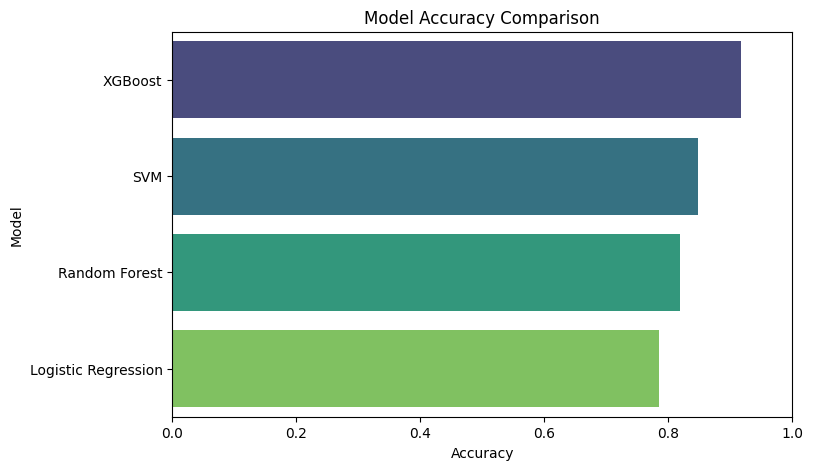

In [48]:
plt.figure(figsize=(8,5))
sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlim(0, 1)
plt.show()


📊 9. MODEL COMPARISON


In [17]:
results


{'Logistic Regression': 0.7850725639253628,
 'SVM': 0.848652384243262,
 'Random Forest': 0.8203178991015895,
 'XGBoost': 0.9177608845888044}

 10. FINAL MODEL (XGBOOST)


In [18]:
xgb_model = models["XGBoost"]
joblib.dump(xgb_model, "xgboost_model.pkl")


['xgboost_model.pkl']

CONFUSION MATRIX (Code)

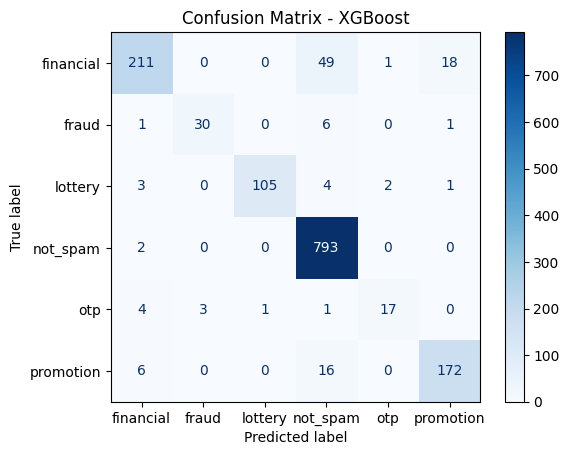

In [49]:
xgb_preds = xgb_model.predict(X_test)
cm = confusion_matrix(y_test, xgb_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - XGBoost')
plt.show()


CLASSIFICATION REPORT TABLE (Code)

In [50]:
report_df = pd.DataFrame(classification_report(y_test, xgb_preds, output_dict=True)).transpose()
report_df


,precision,recall,f1-score,support
0,0.929515,0.756272,0.833992,279.000000
1,0.909091,0.789474,0.845070,38.000000
2,0.990566,0.913043,0.950226,115.000000
3,0.912543,0.997484,0.953125,795.000000
4,0.850000,0.653846,0.739130,26.000000
5,0.895833,0.886598,0.891192,194.000000
accuracy,0.917761,0.917761,0.917761,0.917761
macro avg,0.914591,0.832786,0.868789,1447.000000
weighted avg,0.918562,0.917761,0.914938,1447.000000


ACTUAL VS PREDICTED CSV (Code)

In [51]:
predictions_df = pd.DataFrame({
    'actual_label': le.inverse_transform(y_test),
    'predicted_label': le.inverse_transform(xgb_preds)
})

predictions_df['is_correct'] = predictions_df['actual_label'] == predictions_df['predicted_label']
predictions_df.to_csv('predictions_results.csv', index=False)
predictions_df.head()


,actual_label,predicted_label,is_correct
0,not_spam,not_spam,True
1,not_spam,not_spam,True
2,not_spam,not_spam,True
3,not_spam,not_spam,True
4,promotion,promotion,True


 11. SHAP EXPLAINABILITY (XGBOOST ONLY)


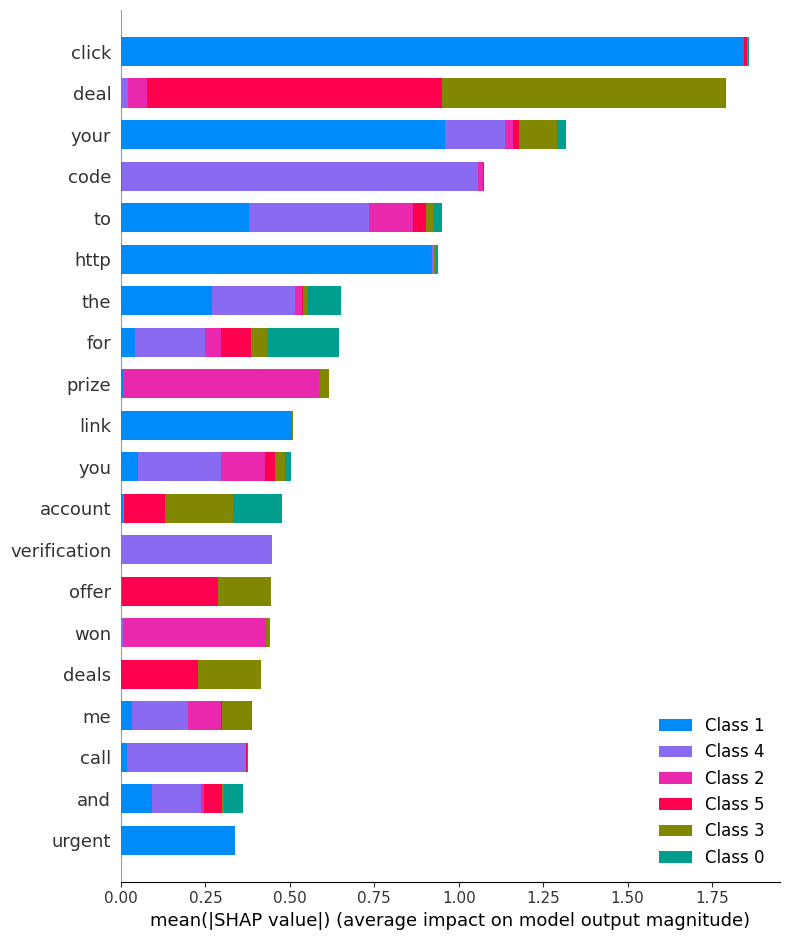

In [19]:
explainer = shap.Explainer(xgb_model)
sample = X_test[:100]

shap_values = explainer(sample)

shap.summary_plot(shap_values, feature_names=tfidf.get_feature_names_out())


⚡ 12. ACTIVE LEARNING LOOP (UNCERTAIN SAMPLES)


In [20]:
probs = xgb_model.predict_proba(X_test)

uncertain_idx = np.where(np.max(probs, axis=1) < 0.6)

print("Uncertain samples:", len(uncertain_idx))

uncertain_samples = df.iloc[uncertain_idx][['TEXT', 'label']]
uncertain_samples.head()


Uncertain samples: 1


,TEXT,label
52,Ok... C ya...,not_spam
53,Are you this much buzy�.I don�t think so,not_spam
60,"0A$NETWORKS allow companies to bill for SMS, s...",financial
77,is your hamster dead? Hey so tmr i meet you at...,not_spam
103,Is fujitsu s series lifebook good?,not_spam


Download csv,with actual and the predicted value


In [36]:
# Get actual labels and predictions for XGBoost (MAIN MODEL)
y_test_actual = le.inverse_transform(y_test)
y_test_predicted = le.inverse_transform(xgb_model.predict(X_test))  # Fresh predictions

# Get test indices (this was the problem - X_test.indices doesn't exist)
test_indices = X_test_indices  # Store indices earlier in Step 7

# Create predictions DataFrame
predictions_df = pd.DataFrame({
    'TEXT': df.iloc[test_indices]['TEXT'].values,  # Original text
    'actual_label': y_test_actual,
    'predicted_label': y_test_predicted,
    'is_correct': y_test_actual == y_test_predicted
})

# Save to CSV
predictions_df.to_csv('predictions_results.csv', index=False)
print("✅ Predictions saved to predictions_results.csv")
print("\nSample:")
print(predictions_df.head())
print(f"\nTotal predictions: {len(predictions_df)}")
print(f"Accuracy: {predictions_df['is_correct'].mean():.3f}")

✅ Predictions saved to predictions_results.csv

Sample:
                                                TEXT actual_label  \
0  naturally busty helen . . fickle the eyes spea...     not_spam   
1  Forgot you were working today! Wanna chat, but...     not_spam   
2  Ok lor. I ned 2 go toa payoh 4 a while 2 retur...     not_spam   
3  sear robin revisions effective 6 / 10 / 00 ( s...     not_spam   
4  real teens love make sex ( tons of video ) bea...    promotion   

  predicted_label  is_correct  
0        not_spam        True  
1        not_spam        True  
2        not_spam        True  
3        not_spam        True  
4       promotion        True  

Total predictions: 1447
Accuracy: 0.918


 13. DISTILBERT MODEL (DEEP LEARNING)


In [21]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torch.utils.data import Dataset, DataLoader

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Dataset class


In [22]:
class SMSDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx])
        }


Prepare dataset

In [23]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['clean_text'].tolist(),
    df['label_encoded'].tolist(),
    test_size=0.2
)

train_dataset = SMSDataset(train_texts, train_labels)
test_dataset = SMSDataset(test_texts, test_labels)

train_loader = DataLoader(train_dataset, batch_size=8)


Load DistilBERT

In [24]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(le.classes_)
)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training loop (simple)

In [27]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=2e-5)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

model.train()

for epoch in range(3):
    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()
        optimizer.step()

    print("Epoch done - Loss:", loss.item())


Epoch done - Loss: 0.12188253551721573
Epoch done - Loss: 0.6212719678878784
Epoch done - Loss: 0.031426116824150085


13.5. SAVE DISTILBERT MODEL FILES

In [37]:
# Save fine-tuned DistilBERT model and tokenizer
model.save_pretrained("distilbert_sms_model")
tokenizer.save_pretrained("distilbert_sms_model")

print("DistilBERT model and tokenizer saved successfully!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT model and tokenizer saved successfully!


14. FINAL MODEL SUMMARY OUTPUT

In [28]:
print("\\nMODEL PERFORMANCE SUMMARY")
for k, v in results.items():
    print(k, ":", v)


\nMODEL PERFORMANCE SUMMARY
Logistic Regression : 0.7850725639253628
SVM : 0.848652384243262
Random Forest : 0.8203178991015895
XGBoost : 0.9177608845888044


 15. DOWNLOAD FILES

In [38]:
model.save_pretrained("distilbert_sms_model")
tokenizer.save_pretrained("distilbert_sms_model")

SameFileError: 'xgboost_model.pkl' and '/content/xgboost_model.pkl' are the same file

In [ ]:
import os
from google.colab import files

# 1. Define path and ZIP name
folder_path   = "/content/your_folder"          # change this to your folder path
zip_filename  = "your_folder.zip"

# 2. Zip the folder (recursive)
!zip -r {zip_filename} {folder_path}

# 3. Download the ZIP to your local machine
files.download(zip_filename)

In [39]:
import os

# Get a list of all files and directories in the current working directory
current_directory_contents = os.listdir('/content/')

print('Files and their sizes in /content/ directory:')
for item in current_directory_contents:
    item_path = os.path.join('/content/', item)
    if os.path.isfile(item_path):
        size_bytes = os.path.getsize(item_path)
        size_mb = size_bytes / (1024 * 1024)
        print(f'- {item}: {size_mb:.2f} MB')
    elif os.path.isdir(item_path):
        # For directories, you might want to calculate total size or just list them
        print(f'- {item}/ (directory)')

Files and their sizes in /content/ directory:
- .config/ (directory)
- label_encoder.pkl: 0.00 MB
- predictions_results.csv: 1.04 MB
- SMS_labelled_CSV.csv: 9.91 MB
- vectorizer.pkl: 0.17 MB
- distilbert_sms_model/ (directory)
- xgboost_model.pkl: 0.84 MB
- sample_data/ (directory)
